YOLO V8 pre entrenado con COCO, se aplicara finetunning para detectar mascarillas en imagenes

## Setup

In [79]:
!pip install --upgrade git+https://github.com/keras-team/keras-cv -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [80]:
!pip install tensorflow

In [81]:
!pip install opencv-python

In [82]:
import os
from tqdm.auto import tqdm
import xml.etree.ElementTree as ET
import numpy as np

import tensorflow as tf
from tensorflow import keras

import keras_cv
from keras_cv import bounding_box
from keras_cv import visualization

from tensorflow.keras import callbacks
import matplotlib.pyplot as plt

import cv2

## Hyperparameters

In [83]:
SPLIT_RATIO = 0.2
BATCH_SIZE = 4
LEARNING_RATE = 0.001
EPOCH = 5
GLOBAL_CLIPNORM = 10.0

In [84]:
class_ids = ["mask"]
class_mapping = dict(zip(range(len(class_ids)), class_ids))

# Path to images and annotations
path_images = "cubrebocas"
path_annot = "cubrebocas"

# Get all XML file paths in path_annot and sort them
xml_files = sorted(
    [
        os.path.join(path_annot, file_name)
        for file_name in os.listdir(path_annot)
        if file_name.endswith(".xml")
    ]
)

# Get all JPEG image file paths in path_images and sort them
jpg_files = sorted(
    [
        os.path.join(path_images, file_name)
        for file_name in os.listdir(path_images)
        if file_name.endswith(".jpg")
    ]
)

In [85]:
jpg_files

['cubrebocas/maksssksksss101_png.rf.4b958ca4d9ef360e4c24d11dca95923a.jpg',
 'cubrebocas/maksssksksss106_png.rf.29fc99081375b1c92e17c3efe603cccf.jpg',
 'cubrebocas/maksssksksss107_png.rf.6e722bc2046681cde6af04751143bdd3.jpg',
 'cubrebocas/maksssksksss109_png.rf.82188f8e37daab95543be3e67422ee13.jpg',
 'cubrebocas/maksssksksss10_png.rf.d9806a6ed9f5baafda50a3412819eb5f.jpg',
 'cubrebocas/maksssksksss117_png.rf.612696bc4dec39da0305eb7895cf1e00.jpg',
 'cubrebocas/maksssksksss120_png.rf.58bc7e4cea030226d4812b60f971d2b5.jpg',
 'cubrebocas/maksssksksss123_png.rf.9496ba52837cdbc2ba2e77f321d98ce4.jpg',
 'cubrebocas/maksssksksss126_png.rf.8e1d5b56a84dd41b0a19365160fc8879.jpg',
 'cubrebocas/maksssksksss133_png.rf.ee71cea267245fb93b1b5e4a7cb00d77.jpg',
 'cubrebocas/maksssksksss135_png.rf.e6c972d64a521ee0d6bfec6a13971886.jpg',
 'cubrebocas/maksssksksss138_png.rf.e5b59c3d6f3719cf8ab91e402390fdcf.jpg',
 'cubrebocas/maksssksksss140_png.rf.13eda79eb5694c9433afa3fde71d540a.jpg',
 'cubrebocas/maksssksksss1

In [86]:
def parse_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    image_name = root.find("filename").text
    image_path = os.path.join(path_images, image_name)

    boxes = []
    classes = []
    for obj in root.iter("object"):
        cls = obj.find("name").text
        classes.append(cls)

        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)
        boxes.append([xmin, ymin, xmax, ymax])

    class_ids = [
        list(class_mapping.keys())[list(class_mapping.values()).index(cls)]
        for cls in classes
    ]
    return image_path, boxes, class_ids


image_paths = []
bbox = []
classes = []
for xml_file in tqdm(xml_files):
    image_path, boxes, class_ids = parse_annotation(xml_file)
    image_paths.append(image_path)
    bbox.append(boxes)
    classes.append(class_ids)

  0%|          | 0/100 [00:00<?, ?it/s]

In [87]:
classes

[[0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0],
 [0],
 [0, 0],
 [0, 0, 0],
 [0, 0],
 [0],
 [0],
 [0, 0],
 [0],
 [0, 0, 0, 0, 0],
 [0],
 [0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0],
 [0],
 [0],
 [0, 0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0, 0],
 [0],
 [0],
 [0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0, 0, 0, 0, 0, 0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 0],
 [0],
 [0],
 [0],
 [0],
 [0]]

In [88]:
bbox

[[[101.0, 521.0, 343.0, 641.0]],
 [[163.0, 174.0, 572.0, 628.0]],
 [[235.0, 358.0, 467.0, 502.0]],
 [[340.0, 206.0, 604.0, 400.0]],
 [[201.0, 472.0, 422.0, 616.0]],
 [[271.0, 398.0, 511.0, 555.0]],
 [[107.0, 337.0, 416.0, 542.0]],
 [[358.0, 312.0, 521.0, 492.0]],
 [[456.0, 102.0, 531.0, 142.0], [241.0, 91.0, 375.0, 172.0]],
 [[205.0, 329.0, 477.0, 508.0]],
 [[240.0, 289.0, 435.0, 559.0], [84.0, 538.0, 236.0, 641.0]],
 [[359.0, 277.0, 502.0, 452.0],
  [76.0, 408.0, 212.0, 574.0],
  [228.0, 445.0, 353.0, 567.0]],
 [[35.0, 282.0, 305.0, 596.0], [334.0, 378.0, 553.0, 613.0]],
 [[168.0, 253.0, 338.0, 433.0]],
 [[141.0, 361.0, 424.0, 542.0]],
 [[232.0, 223.0, 411.0, 367.0], [1.0, 69.0, 134.0, 242.0]],
 [[112.0, 268.0, 350.0, 422.0]],
 [[11.0, 368.0, 102.0, 507.0],
  [339.0, 189.0, 364.0, 226.0],
  [515.0, 135.0, 635.0, 300.0],
  [440.0, 217.0, 464.0, 249.0],
  [248.0, 243.0, 275.0, 280.0]],
 [[112.0, 223.0, 245.0, 346.0]],
 [[165.0, 346.0, 433.0, 495.0]],
 [[17.0, 179.0, 189.0, 311.0], [442.

In [89]:
bbox = tf.ragged.constant(bbox)
classes = tf.ragged.constant(classes)
image_paths = tf.ragged.constant(image_paths)

data = tf.data.Dataset.from_tensor_slices((image_paths, classes, bbox))

Splitting data in training and validation data

In [90]:
# Determine the number of validation samples
num_val = int(len(xml_files) * SPLIT_RATIO)

# Split the dataset into train and validation sets
val_data = data.take(num_val)
train_data = data.skip(num_val)

In [91]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image


def load_dataset(image_path, classes, bbox):
    # Read Image
    image = load_image(image_path)
    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox,
    }
    return {"images": tf.cast(image, tf.float32), "bounding_boxes": bounding_boxes}


In [92]:
augmenter = keras.Sequential(
    layers=[
        keras_cv.layers.RandomFlip(mode="horizontal", bounding_box_format="xyxy"),
        keras_cv.layers.RandomShear(
            x_factor=0.2, y_factor=0.2, bounding_box_format="xyxy"
        ),
        keras_cv.layers.JitteredResize(
            target_size=(640, 640), scale_factor=(0.75, 1.3), bounding_box_format="xyxy"
        ),
    ]
)

## Creating Training Dataset

In [93]:
train_ds = train_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BATCH_SIZE * 4)
train_ds = train_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
train_ds = train_ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)

## Creating Validation Dataset

In [94]:
resizing = keras_cv.layers.JitteredResize(
    target_size=(640, 640),
    scale_factor=(0.75, 1.3),
    bounding_box_format="xyxy",
)

val_ds = val_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(BATCH_SIZE * 4)
val_ds = val_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.map(resizing, num_parallel_calls=tf.data.AUTOTUNE)

## Visualization

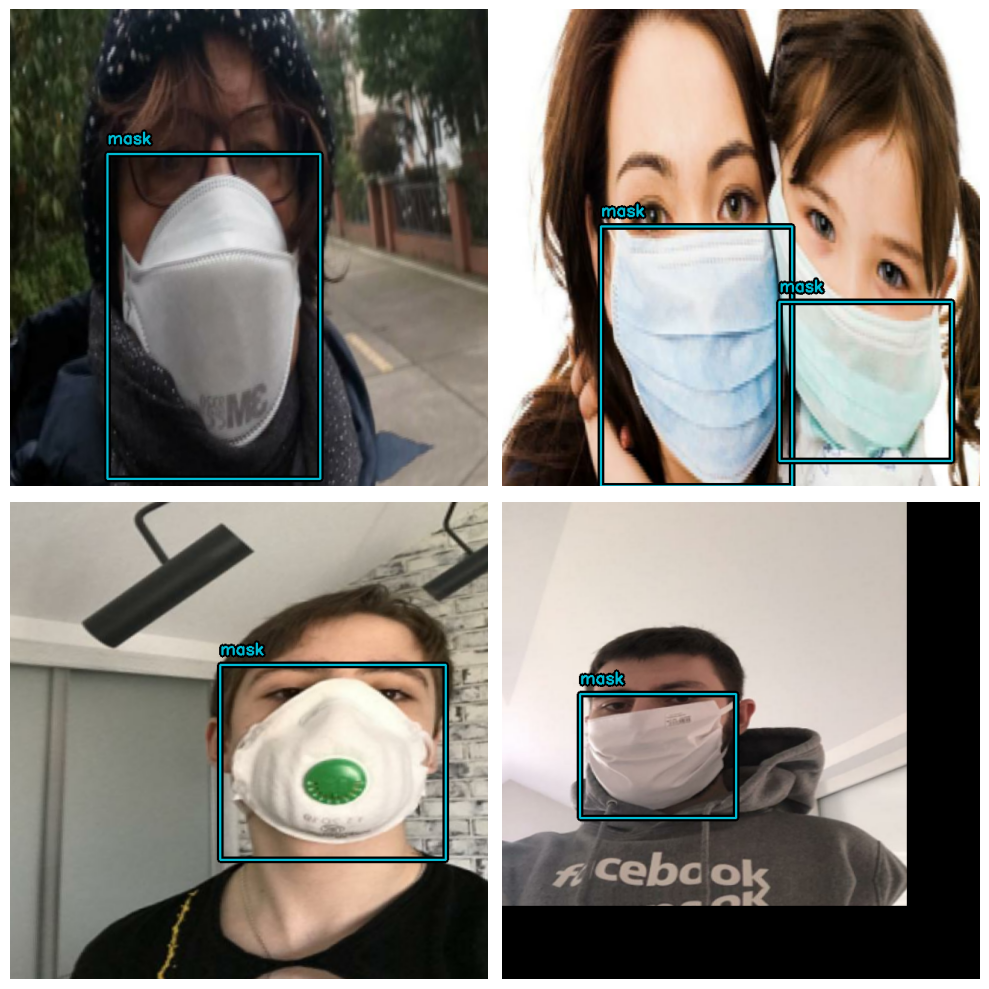

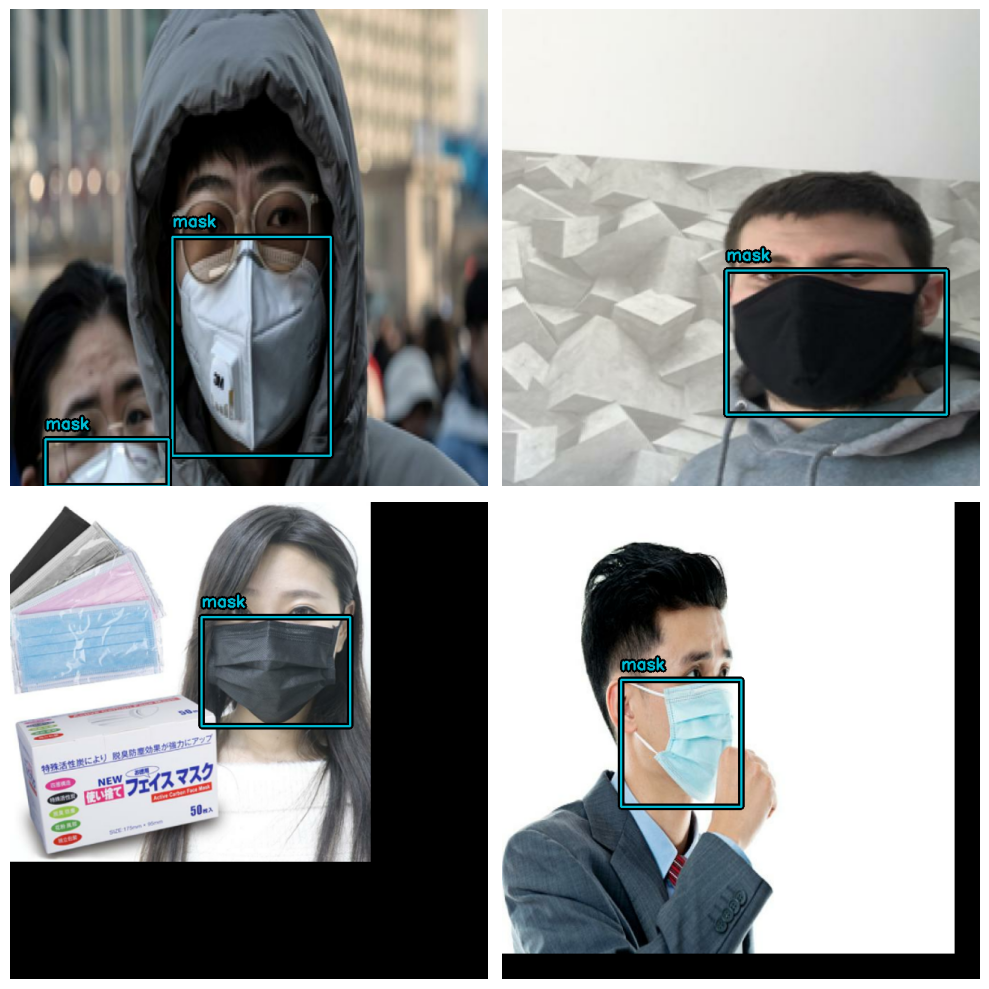

In [95]:
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs["images"], inputs["bounding_boxes"]
    visualization.plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale=5,
        font_scale=0.7,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
    )


visualize_dataset(
    train_ds, bounding_box_format="xyxy", value_range=(0, 255), rows=2, cols=2
)

visualize_dataset(
    val_ds, bounding_box_format="xyxy", value_range=(0, 255), rows=2, cols=2
)

In [96]:
def dict_to_tuple(inputs):
    return inputs["images"], inputs["bounding_boxes"]


train_ds = train_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

## Creating Model

You can read more about YOLOV8 and its architecture in this
[RoboFlow Blog](https://blog.roboflow.com/whats-new-in-yolov8/)

In [97]:
backbone = keras_cv.models.YOLOV8Backbone.from_preset(
    "yolo_v8_s_backbone_coco"  # We will use yolov8 small backbone with coco weights
)

In [98]:
yolo = keras_cv.models.YOLOV8Detector(
    num_classes=len(class_mapping),
    bounding_box_format="xyxy",
    backbone=backbone,
    fpn_depth=1,
)

## Compile the Model

In [99]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    global_clipnorm=GLOBAL_CLIPNORM,
)

In [100]:
yolo.compile(
    optimizer=optimizer, classification_loss="binary_crossentropy", box_loss="ciou"
)

In [101]:
checkpoint = callbacks.ModelCheckpoint('yolo.keras', monitor = 'val_loss', save_best_only=True, mode = 'min')

## Train the Model

In [102]:
M = yolo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint]
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - box_loss: 2.4556 - class_loss: 385.2101 - loss: 387.6657 - val_box_loss: 2.9589 - val_class_loss: 4973.8701 - val_loss: 4976.8291
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - box_loss: 2.4245 - class_loss: 136.0405 - loss: 138.4650 - val_box_loss: 3.8095 - val_class_loss: 1067.8396 - val_loss: 1071.6492
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - box_loss: 2.4209 - class_loss: 75.4293 - loss: 77.8503 - val_box_loss: 3.3371 - val_class_loss: 122.3689 - val_loss: 125.7060
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - box_loss: 2.2568 - class_loss: 34.3624 - loss: 36.6192 - val_box_loss: 3.5309 - val_class_loss: 170.7914 - val_loss: 174.3223
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - box_loss: 2.3629 - class_loss: 17.8822 - loss: 20.2451 - val_box_loss: 3.6194 - val_class_loss: 59.2284 - val_loss: 62.8478
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - box_loss: 2.3736 - class_loss: 9.5643 - loss: 

## Evaluation

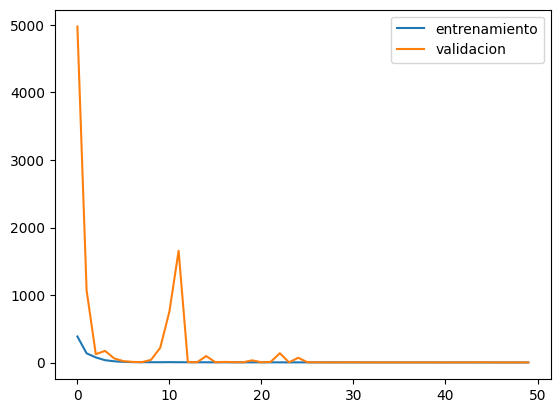

In [103]:
# Grafica del error del modelo
plt.plot(M.history['loss'], label ='entrenamiento')
plt.plot(M.history['val_loss'], label ='validacion')
plt.legend(loc = 'best')
plt.show()

## Visualize Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


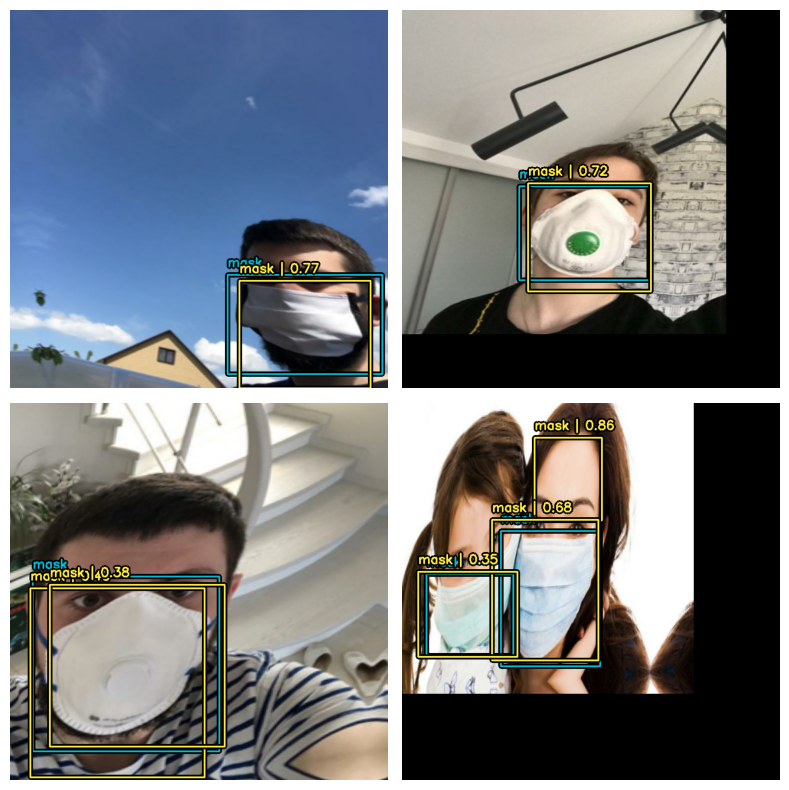

In [104]:
def visualize_detections(model, dataset, bounding_box_format):
    images, y_true = next(iter(dataset.take(1)))
    y_pred = model.predict(images)
    y_pred['boxes'] = y_pred['boxes'][:, 0:3, :]
    y_pred['confidence'] = y_pred['confidence'][:, 0:3]
    y_pred['classes'] = y_pred['classes'][:, 0:3]
    #y_pred = bounding_box.to_ragged(y_pred)
    visualization.plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        scale=4,
        rows=2,
        cols=2,
        show=True,
        font_scale=0.7,
        class_mapping=class_mapping,
    )

visualize_detections(yolo, dataset=train_ds, bounding_box_format="xyxy")